# Binary Classification Experiment

Based on the data distribution visualized with the experiments in "analysing_datamodels_training", it seem that a datamodel training with binary classification makes more sense for this type of problem. In this notebook we will:
- Expose de setup of this experiment
- Analyze the distributions
- Create and evaluate binary classification models with AUC Score
- Analyze the text generations evaluation on Rouge-L

## Experiment Setup

Before this notebook the following steps were made:
- Copied the "instruction_1" questions from "debugging_rag_recall_vllm_vs_hfpipeline/validating_datamodels" subset of training questions and rag retrieval into "runs" subfolder.
- Copied the already aggregated "collections/groundtruth" Rouge-L score generations score using the groundtruth small answers from the experiment "analysing_datamodels_training" into the subfolder "groundtruth"
- Run the script "scripts/judge_collection.sh" to try to collect an unsupervised binary score using a LLM-as-a-Judge approach.:
    - It was used five GPUs H200 to create the collection
    - It was explicity indicated the usage of values 0 and 1 to indicate the quality of an answers as BAD or GOOD, respectively.
    - Collections saved inside the "datamodels/collections" of each expirement folder in "runs" with the chekcpois name with "
- Run the script "create_binary_collections.py" to transform the groundtruth ROGUE-L scores into a binary classification problem saving into the subfolder "binary_collections/groundtruth" and to aggregate the judge binary classifications in to the subfolder "binary_collections/judge"
- Run the script "run_logreg_gridsearch.py" in order to find the best parameters for each sample. It's necessary to run all combinations of "exp-index" (0-4) and "subfolder" ("groundtruth" or "judge"). This will save the best parameters in the folder "best_params" 

## Notebook Setup

In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gc
import torch
import types
import sys
from utils.set_random_seed import set_random_seed

set_random_seed(42)
EXPERIMENTS = ["experiment_1", "experiment_4", "experiment_54", "experiment_61", "experiment_73"]

In [ ]:
def get_train_sets(df):
    groundtruth_train = df.filter((pl.col("subfolder") == "groundtruth") & (pl.col("split") == "train"))
    judge_train = df.filter((pl.col("subfolder") == "judge") & (pl.col("split") == "train"))
    
    X_groundtruth_train = []
    y_groundtruth_train = []
    X_judge_train = []
    y_judge_train = []


    for exp in EXPERIMENTS:
        gt_exp = groundtruth_train.filter(pl.col("experiment") == exp)
        jd_exp = judge_train.filter(pl.col("experiment") == exp)
        
        X_gt_exp = gt_exp.select("input").to_numpy()
        X_gt_exp = np.array([i[0] for i in X_gt_exp])
        y_gt_exp = gt_exp.select("evaluation").to_numpy()
        
        X_jd_exp = jd_exp.select("input").to_numpy()
        X_jd_exp = np.array([i[0] for i in X_jd_exp])
        y_jd_exp = jd_exp.select("evaluation").to_numpy()

        # Reshape into 500 arrays with 2000 samples each
        # Data is interleaved: first 500 elements go to position 0 of each array,
        # next 500 elements go to position 1 of each array, etc.
        total_samples = len(X_gt_exp)
        num_arrays = 500
        samples_per_array = total_samples // num_arrays
        
        # Reshape groundtruth data: (500*2000,) -> (500, 2000)
        X_gt_reshaped = []
        y_gt_reshaped = []
        for i in range(num_arrays):
            # Take every 500th element starting from index i
            X_gt_reshaped.append(X_gt_exp[i::num_arrays])
            y_gt_reshaped.append(y_gt_exp[i::num_arrays])
        
        # Reshape judge data: (500*2000,) -> (500, 2000)
        X_jd_reshaped = []
        y_jd_reshaped = []
        for i in range(num_arrays):
            # Take every 500th element starting from index i
            X_jd_reshaped.append(X_jd_exp[i::num_arrays])
            y_jd_reshaped.append(y_jd_exp[i::num_arrays])

        X_groundtruth_train.append(X_gt_reshaped)
        y_groundtruth_train.append(y_gt_reshaped)
        X_judge_train.append(X_jd_reshaped)
        y_judge_train.append(y_jd_reshaped)

    return X_groundtruth_train, y_groundtruth_train, X_judge_train, y_judge_train

def get_test_sets(df):
    groundtruth_test = df.filter((pl.col("subfolder") == "groundtruth") & (pl.col("split") == "test"))
    judge_test = df.filter((pl.col("subfolder") == "judge") & (pl.col("split") == "test"))

    X_groundtruth_test = []
    y_groundtruth_test = []
    X_judge_test = []
    y_judge_test = []

    for exp in EXPERIMENTS:
        gt_exp = groundtruth_test.filter(pl.col("experiment") == exp)
        jd_exp = judge_test.filter(pl.col("experiment") == exp)

        X_gt_exp = gt_exp.select("input").to_numpy()
        X_gt_exp = np.array([i[0] for i in X_gt_exp])
        y_gt_exp = gt_exp.select("evaluation").to_numpy()
        
        X_jd_exp = jd_exp.select("input").to_numpy()
        X_jd_exp = np.array([i[0] for i in X_jd_exp])
        y_jd_exp = jd_exp.select("evaluation").to_numpy()

        # Reshape into 500 arrays with 200 samples each
        # Data is interleaved: first 500 elements go to position 0 of each array,
        # next 500 elements go to position 1 of each array, etc.
        total_samples = len(X_gt_exp)
        num_arrays = 500
        samples_per_array = total_samples // num_arrays
        
        # Reshape groundtruth data: (500*200,) -> (500, 200)
        X_gt_reshaped = []
        y_gt_reshaped = []
        for i in range(num_arrays):
            # Take every 500th element starting from index i
            X_gt_reshaped.append(X_gt_exp[i::num_arrays])
            y_gt_reshaped.append(y_gt_exp[i::num_arrays])
        
        # Reshape judge data: (500*200,) -> (500, 200)
        X_jd_reshaped = []
        y_jd_reshaped = []
        for i in range(num_arrays):
            # Take every 500th element starting from index i
            X_jd_reshaped.append(X_jd_exp[i::num_arrays])
            y_jd_reshaped.append(y_jd_exp[i::num_arrays])

        X_groundtruth_test.append(X_gt_reshaped)
        y_groundtruth_test.append(y_gt_reshaped)
        X_judge_test.append(X_jd_reshaped)
        y_judge_test.append(y_jd_reshaped)

    return X_groundtruth_test, y_groundtruth_test, X_judge_test, y_judge_test

In [24]:
X_test, y_test, _, _ = get_test_sets(df)


In [25]:
len(X_test[0][1])

200

In [6]:
import os

df = []

for subfolder in ["judge", "groundtruth"]:
    for exp in EXPERIMENTS:
        for split in ["train", "test"]:
            try:
                load_df = pl.read_ipc(f"binary_collections/{subfolder}/{exp}/{split}.feather")
                load_df = load_df.with_columns([
                    pl.lit(subfolder).alias("subfolder"),
                    pl.lit(exp).alias("experiment"),
                    pl.lit(split).alias("split"),
                ])
                df.append(load_df)
            except Exception as e:
                print(f"Could not load {subfolder}/{exp}/{split}: {e}")
df = pl.concat(df)
df.head()

collection_idx,test_idx,input,evaluation,subfolder,experiment,split
i64,i64,"array[i64, 100]",i32,str,str,str
0,0,"[0, 1, … 0]",1,"""judge""","""experiment_1""","""train"""
0,1,"[0, 1, … 0]",1,"""judge""","""experiment_1""","""train"""
0,2,"[0, 1, … 0]",0,"""judge""","""experiment_1""","""train"""
0,3,"[0, 1, … 0]",0,"""judge""","""experiment_1""","""train"""
0,4,"[0, 1, … 0]",1,"""judge""","""experiment_1""","""train"""


## Exploring Distribution

In [ ]:
groundtruth_train = df.filter((pl.col("subfolder") == "groundtruth") & (pl.col("split") == "train"))
groundtruth_test = df.filter((pl.col("subfolder") == "groundtruth") & (pl.col("split") == "test"))
judge_train = df.filter((pl.col("subfolder") == "judge") & (pl.col("split") == "train"))
judge_test = df.filter((pl.col("subfolder") == "judge") & (pl.col("split") == "test"))

/tmp/ipykernel_2893179/3528381416.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gt_train_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[0])
/tmp/ipykernel_2893179/3528381416.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gt_test_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[1])


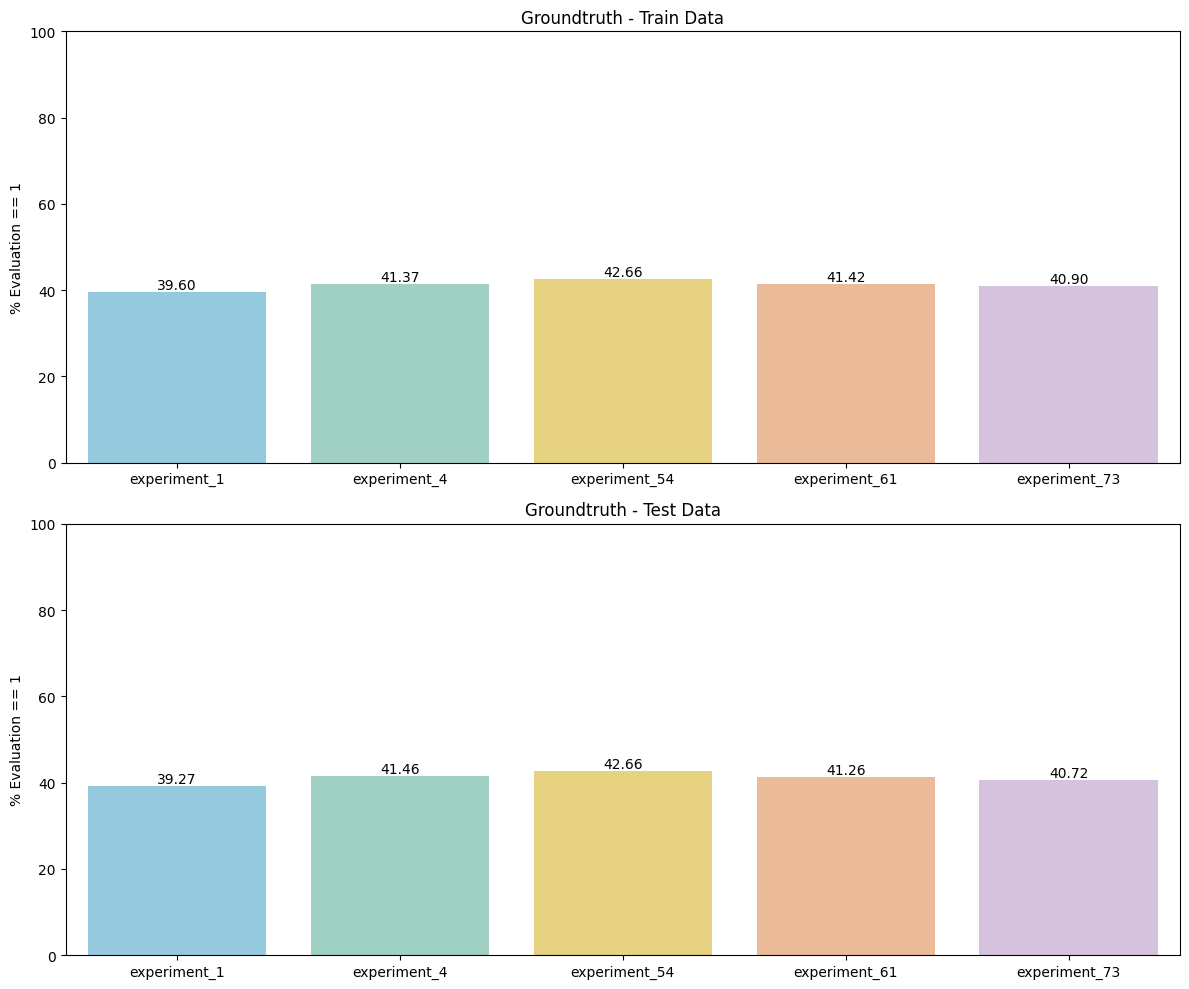

In [ ]:
# Groundtruth Analysis - % of evaluation == 1 for train and test
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Prepare data for train split
gt_train_data = []
for exp in EXPERIMENTS:
    gt_exp = groundtruth_train.filter(pl.col("experiment") == exp)
    pct = (gt_exp.filter(pl.col("evaluation") == 1).height / gt_exp.height) * 100
    gt_train_data.append({"experiment": exp, "percentage": pct})
gt_train_df = pl.DataFrame(gt_train_data)

# Plot train data
pastel_colors = ["#87CEEB", "#98D8C8", "#F7DC6F", "#F8B88B", "#D7BDE2"]  # Pastel colors
sns.barplot(data=gt_train_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[0])
axes[0].set_title("Groundtruth - Train Data")
axes[0].set_ylabel("% Evaluation == 1")
axes[0].set_ylim(0, 100)
axes[0].set_xlabel("")

# Add value labels on top of bars
for patch in axes[0].patches:
    height = patch.get_height()
    axes[0].text(patch.get_x() + patch.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

# Prepare data for test split
gt_test_data = []
for exp in EXPERIMENTS:
    gt_exp = groundtruth_test.filter(pl.col("experiment") == exp)
    pct = (gt_exp.filter(pl.col("evaluation") == 1).height / gt_exp.height) * 100
    gt_test_data.append({"experiment": exp, "percentage": pct})
gt_test_df = pl.DataFrame(gt_test_data)

# Plot test data
sns.barplot(data=gt_test_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[1])
axes[1].set_title("Groundtruth - Test Data")
axes[1].set_ylabel("% Evaluation == 1")
axes[1].set_ylim(0, 100)
axes[1].set_xlabel("")

# Add value labels on top of bars
for patch in axes[1].patches:
    height = patch.get_height()
    axes[1].text(patch.get_x() + patch.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2893179/860813479.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=jd_train_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[0])
/tmp/ipykernel_2893179/860813479.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=jd_test_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[1])


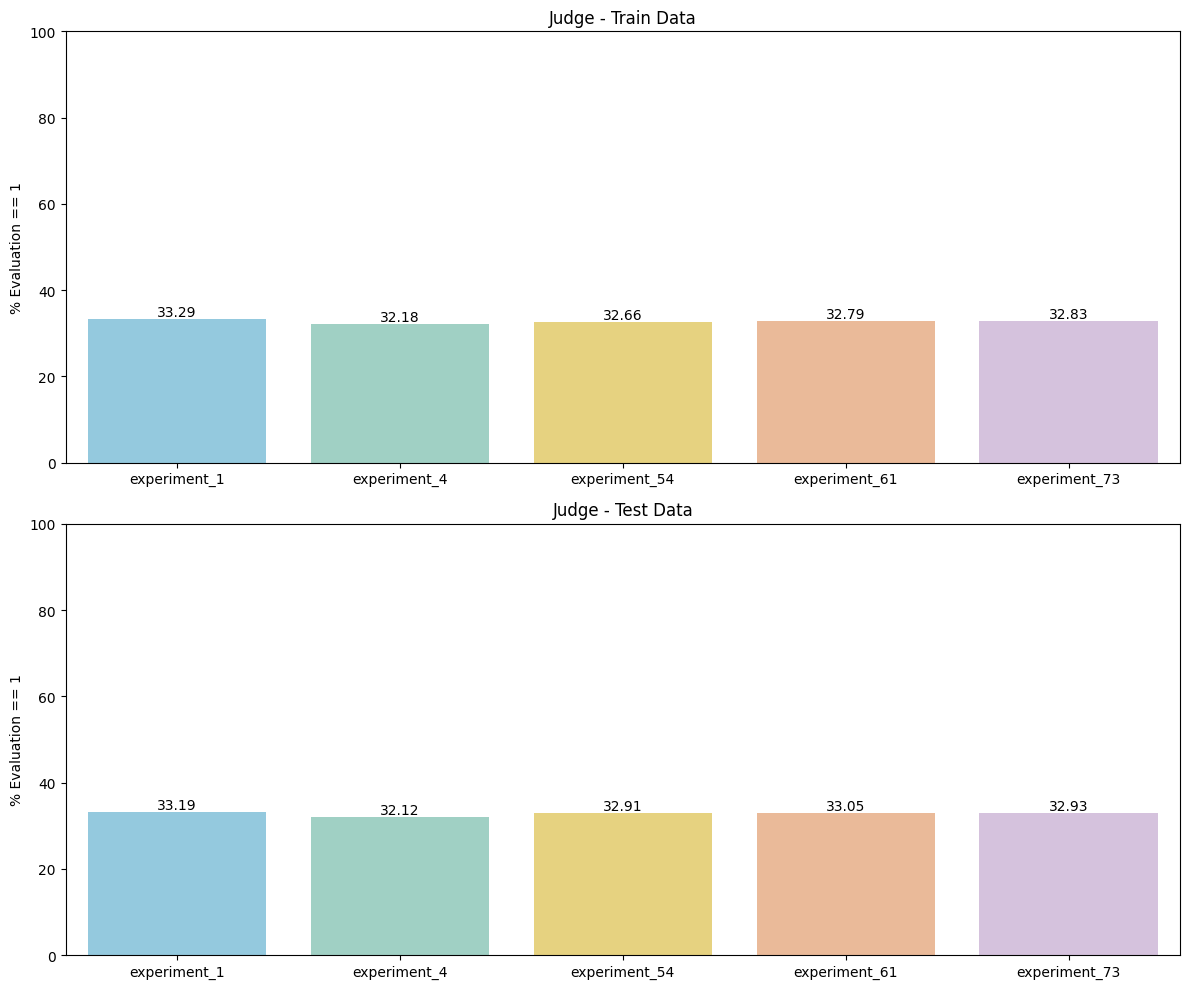

In [ ]:
# Judge Analysis - % of evaluation == 1 for train and test
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Prepare data for train split
jd_train_data = []
for exp in EXPERIMENTS:
    jd_exp = judge_train.filter(pl.col("experiment") == exp)
    pct = (jd_exp.filter(pl.col("evaluation") == 1).height / jd_exp.height) * 100
    jd_train_data.append({"experiment": exp, "percentage": pct})
jd_train_df = pl.DataFrame(jd_train_data)

# Plot train data
pastel_colors = ["#87CEEB", "#98D8C8", "#F7DC6F", "#F8B88B", "#D7BDE2"]  # Pastel colors
sns.barplot(data=jd_train_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[0])
axes[0].set_title("Judge - Train Data")
axes[0].set_ylabel("% Evaluation == 1")
axes[0].set_ylim(0, 100)
axes[0].set_xlabel("")

# Add value labels on top of bars
for patch in axes[0].patches:
    height = patch.get_height()
    axes[0].text(patch.get_x() + patch.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

# Prepare data for test split
jd_test_data = []
for exp in EXPERIMENTS:
    jd_exp = judge_test.filter(pl.col("experiment") == exp)
    pct = (jd_exp.filter(pl.col("evaluation") == 1).height / jd_exp.height) * 100
    jd_test_data.append({"experiment": exp, "percentage": pct})
jd_test_df = pl.DataFrame(jd_test_data)

# Plot test data
sns.barplot(data=jd_test_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[1])
axes[1].set_title("Judge - Test Data")
axes[1].set_ylabel("% Evaluation == 1")
axes[1].set_ylim(0, 100)
axes[1].set_xlabel("")

# Add value labels on top of bars
for patch in axes[1].patches:
    height = patch.get_height()
    axes[1].text(patch.get_x() + patch.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Logistic Regression

In [14]:
## Load best param
import json


best_params = {
    "judge": [],
    "groundtruth": []
}

for f in sorted(os.listdir("best_params")):
    _params = []
    results = json.load(open(f"best_params/{f}", "r"))["results"]
    for p in results:
        try:
            _params.append(p["best_params"])
        except KeyError:
            _params.append(None)
    
    if "judge" in f:
        best_params["judge"].append(_params)
    else:
        best_params["groundtruth"].append(_params)


In [15]:
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm

X_groundtruth_train, y_groundtruth_train, X_judge_train, y_judge_train = get_train_sets(df)
groundtruth_models = []
judge_models = []

with tqdm(total=5 * 500, desc="Training models") as pbar:
    for i in range(5):
        _j_arr, _g_arr = [], []
        for j in range(500):
            # Groundtruth model
            X_gt = X_groundtruth_train[i][j]
            y_gt = y_groundtruth_train[i][j].ravel()
            
            if best_params["groundtruth"][i][j] is None:
                _g_arr.append(None)
            else:
                model_gt = LogisticRegression(**best_params["groundtruth"][i][j], max_iter=1000, random_state=42)
                model_gt.fit(X_gt, y_gt)
                _g_arr.append(model_gt)
            # Judge model
            X_jd = X_judge_train[i][j]
            y_jd = y_judge_train[i][j].ravel()

            if best_params["judge"][i][j] is None:
                _j_arr.append(None)
            else:
                model_jd = LogisticRegression(**best_params["judge"][i][j], max_iter=1000, random_state=42)
                model_jd.fit(X_jd, y_jd)
                _j_arr.append(model_jd)
            

            
            pbar.update(1)
        
        groundtruth_models.append(_g_arr)
        judge_models.append(_j_arr)

del X_groundtruth_train, y_groundtruth_train, X_judge_train, y_judge_train
gc.collect()

Training models:   1%|█                                                                                                                                            | 18/2500 [00:01<02:27, 16.86it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models:   9%|████████████▏                                                                                                                               | 217/2500 [00:13<01:28, 25.81it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models:  22%|███████████████████████████████▍                                                                                                            | 561/2500 [00:33<01:48, 17.85it/s]/home/c

5829

In [16]:
### saving weights as tensores



from numpy import float64


for exp in range(len(EXPERIMENTS)):
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models[exp]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/lr_weights.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/lr_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models[exp]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/lr_bias.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/lr_bias.pt")


### saving for datamodels generations
for exp in range(len(EXPERIMENTS)):
    jg_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/lr_judge/"
    gt_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/lr_groundtruth/"
    os.makedirs(jg_path, exist_ok=True)
    os.makedirs(gt_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models[exp]]), f"{gt_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models[exp]]), f"{jg_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models[exp]]), f"{gt_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models[exp]]), f"{jg_path}/0_499_bias.pt")

/tmp/ipykernel_3200580/2625897236.py:9: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models[exp]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/lr_weights.pt")
/tmp/ipykernel_3200580/2625897236.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models[exp]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/lr_bias.pt")
/tmp/ipykernel_3200580/2625897236.py:12: DeprecationWarning: Co

In [17]:
from sklearn.metrics import roc_auc_score
X_groundtruth_test, y_groundtruth_test, X_judge_test, y_judge_test = get_test_sets(df)


_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}


for i in range(5):
    for j in range(500):
        
        judge_lr = judge_models[i][j]
        if judge_lr is not None:

            _x = X_judge_test[i][j]
            _y = y_judge_test[i][j].ravel()
            score = roc_auc_score(_y, judge_lr.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("judge")
            _eval_df["auc"].append(score)

        groundtruth_lr = groundtruth_models[i][j]
        if groundtruth_lr is not None:
            _x = X_groundtruth_test[i][j]
            _y = y_groundtruth_test[i][j].ravel()
            score = roc_auc_score(_y, groundtruth_lr.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("groundtruth")
            _eval_df["auc"].append(score)



del X_groundtruth_test, y_groundtruth_test, X_judge_test, y_judge_test
gc.collect()

/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarnin

0

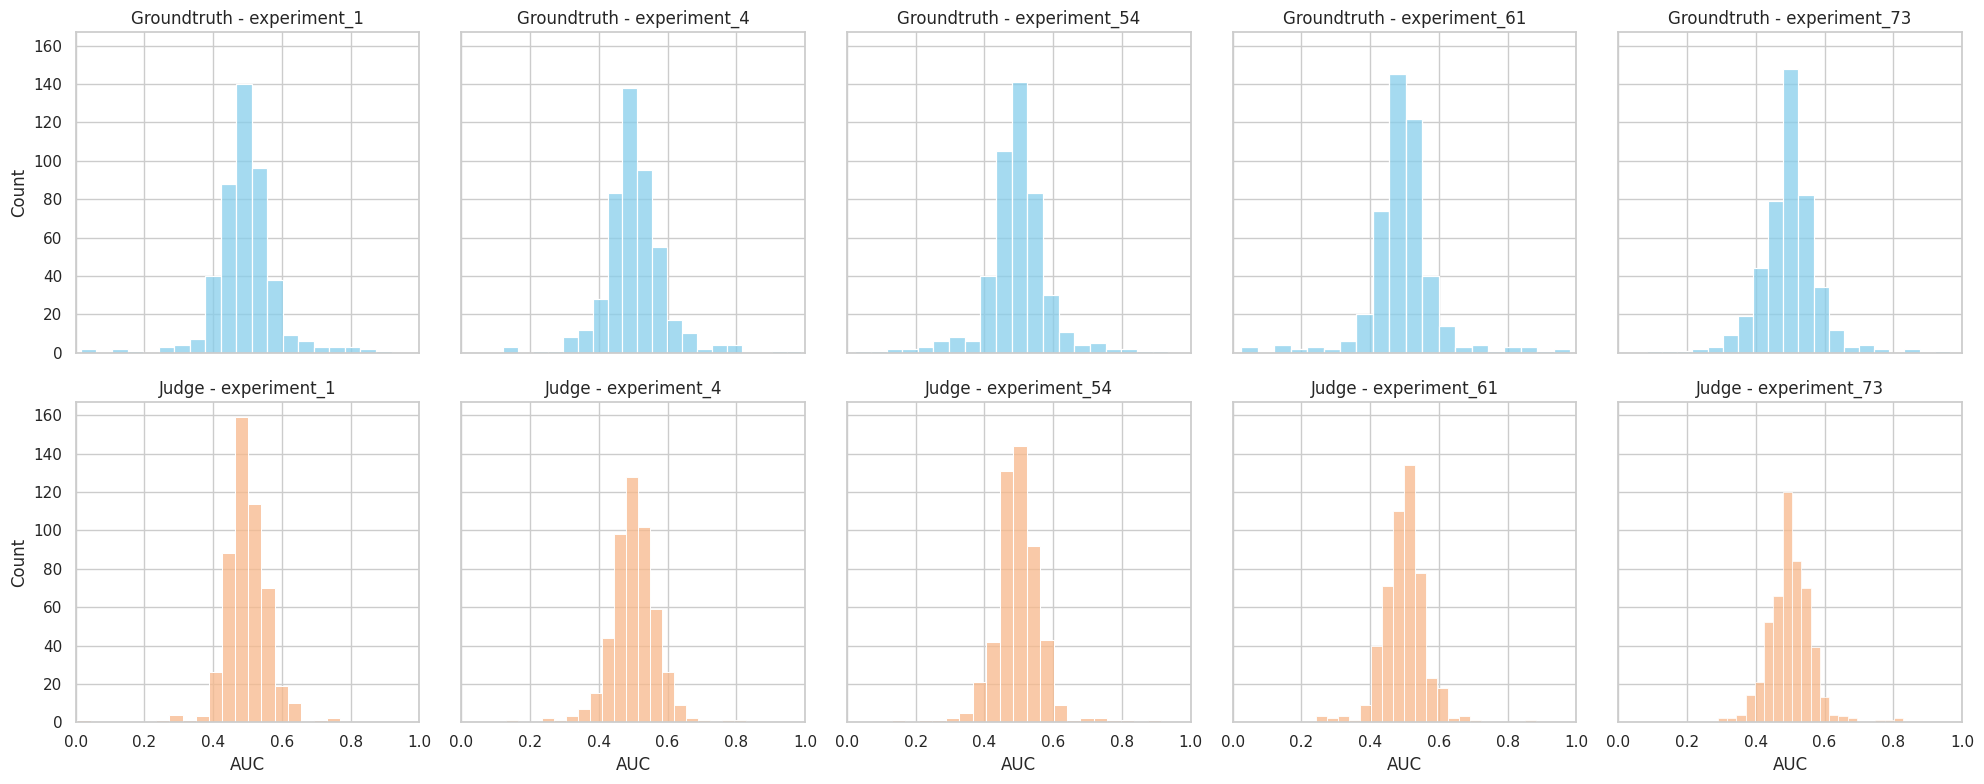

In [18]:
# Plot AUC histograms per type/experiment using existing eval_df (Polars)
import seaborn as sns
import matplotlib.pyplot as plt

eval_df = pl.DataFrame(_eval_df)
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
color_map = {"groundtruth": "#87CEEB", "judge": "#F8B88B"}  # Pastel blue, pastel orange

for row, t in enumerate(["groundtruth", "judge"]):
    for col, exp in enumerate(EXPERIMENTS):
        subset = eval_df.filter((pl.col("type") == t) & (pl.col("experiment") == exp))
        sns.histplot(data=subset.to_pandas(), x="auc", bins=20, color=color_map[t], ax=axes[row, col])
        axes[row, col].set_title(f"{t.capitalize()} - {exp}")
        axes[row, col].set_xlim(0, 1)
        if col == 0:
            axes[row, col].set_ylabel("Count")
        else:
            axes[row, col].set_ylabel("")
        axes[row, col].set_xlabel("AUC")

plt.tight_layout()
plt.show()

## Text Generation Analysis

In [23]:
from utils.metrics.calculate_metric import calculate_agg_metric


wiki = pl.read_ipc(f"../../data/wiki_dump2018_nq_open/processed/wiki.feather")
gold = pl.read_ipc(f"../../data/nq_open_gold/processed/dev.feather")

LOAD = False
if not LOAD:
    dfs_generations = []
    for exp in EXPERIMENTS:
        questions_path = f"runs/{exp}/questions.feather"
        for file in os.listdir(f"runs/{exp}/generations"):
            print(f"Processing {file} for experiment {exp}...")
            dfs_generations.append(calculate_agg_metric(
                metrics=["rouge_l"],
                generation_path=f"runs/{exp}/generations/{file}",
                reference_path=questions_path    ,
                saving_path=None            
            )
            .with_columns([
                pl.lit(exp).alias("experiment"),
                pl.lit(file.split('_')[1].split('.')[0]).alias("model"),
            ]))

    generations_results = pl.concat(dfs_generations)
    generations_results.write_ipc("generation_results/logistic_regression.feather")
else:
    generations_results = pl.read_ipc("generation_results/logistic_regression.feather")        

Processing lr_judge.json for experiment experiment_1...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_groundtruth.json for experiment experiment_1...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_groundtruth.json for experiment experiment_4...


...

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_judge.json for experiment experiment_73...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_groundtruth.json for experiment experiment_73...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


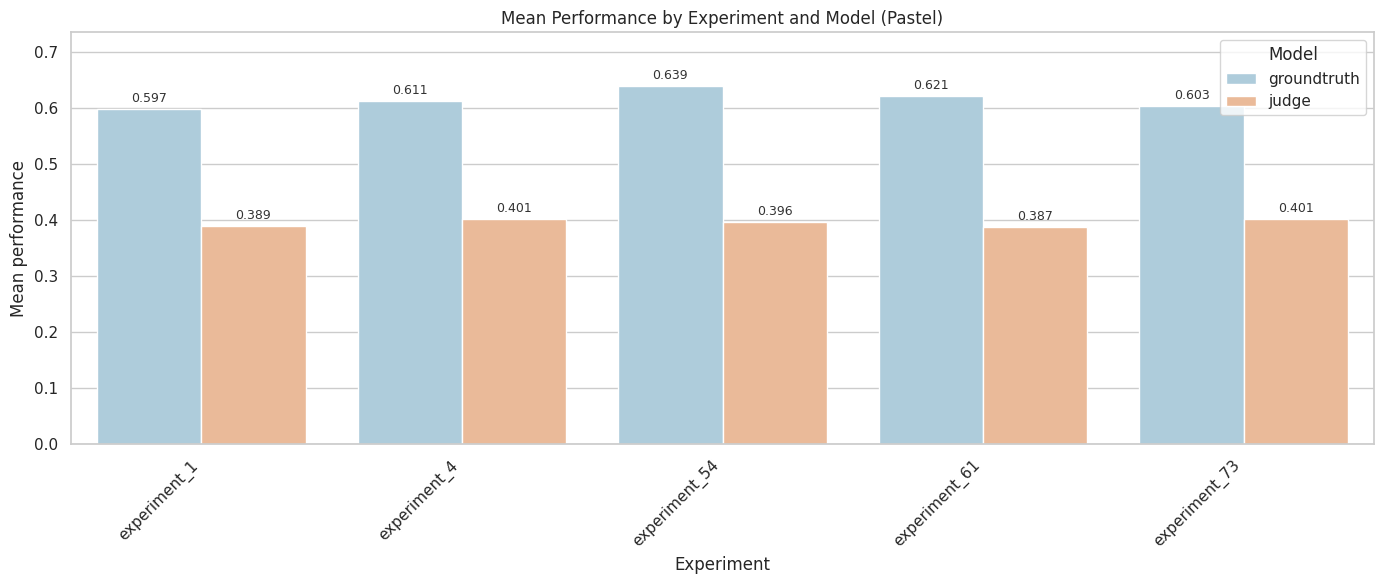

In [24]:
# Ensure the aggregated column is named `mean`
_df = generations_results.group_by(["experiment", "model"]).agg(pl.col("mean").mean())

_cols = _df.columns
if "mean" in _cols:
    df_plot = _df.rename({"mean": "mean"})
elif "mean_mean" in _cols:
    df_plot = _df.rename({"mean_mean": "mean"})
else:
    # Fallback: assume third column is the aggregated mean
    score_col = [c for c in _cols if c not in ("experiment", "model")][0]
    df_plot = _df.rename({score_col: "mean"})

# Convert to pandas for seaborn
_df_pd = df_plot.to_pandas()

# Limit to requested categories to ensure palette mapping works
wanted_models = ["groundtruth", "judge"]
_df_pd = _df_pd[_df_pd["model"].isin(wanted_models)]

# Pastel palette mapping
palette = {
    "groundtruth": "#a6cee3",  # pastel blue
    "judge": "#F8B88B",        # pastel yellow
}

# Order experiments ascending
order_experiments = sorted(_df_pd["experiment"].unique())
hue_order = wanted_models

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=_df_pd,
    x="experiment",
    y="mean",
    hue="model",
    palette=palette,
    order=order_experiments,
    hue_order=hue_order,
)

plt.title("Mean Performance by Experiment and Model (Pastel)")
plt.xlabel("Experiment")
plt.ylabel("Mean performance")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")

# Show numeric labels above bars
try:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9, color="#333")
except Exception:
    # Fallback for older matplotlib versions
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(f"{height:.3f}",
                    (patch.get_x() + patch.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color="#333",
                    xytext=(0, 3), textcoords='offset points')

# Small headroom for labels
if len(_df_pd):
    plt.ylim(0, _df_pd["mean"].max() * 1.15)

plt.tight_layout()
plt.show()

## Training with Class Weights

In [ ]:
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm

X_groundtruth_train, y_groundtruth_train, X_judge_train, y_judge_train = get_train_sets(df)
groundtruth_models = []
judge_models = []

with tqdm(total=5 * 500, desc="Training models") as pbar:
    for i in range(5):
        _j_arr, _g_arr = [], []
        for j in range(500):
            # Groundtruth model
            X_gt = X_groundtruth_train[i][j]
            y_gt = y_groundtruth_train[i][j].ravel()
            
            if best_params["groundtruth"][i][j] is None:
                _g_arr.append(None)
            else:
                model_gt = LogisticRegression(**best_params["groundtruth"][i][j], max_iter=1000, random_state=42, class_weight="balanced")
                model_gt.fit(X_gt, y_gt)
                _g_arr.append(model_gt)
            # Judge model
            X_jd = X_judge_train[i][j]
            y_jd = y_judge_train[i][j].ravel()

            if best_params["judge"][i][j] is None:
                _j_arr.append(None)
            else:
                model_jd = LogisticRegression(**best_params["judge"][i][j], max_iter=1000, random_state=42)
                model_jd.fit(X_jd, y_jd)
                _j_arr.append(model_jd)
            

            
            pbar.update(1)
        
        groundtruth_models.append(_g_arr)
        judge_models.append(_j_arr)

del X_groundtruth_train, y_groundtruth_train, X_judge_train, y_judge_train
gc.collect()

Training models:   0%|▍                                                                                                                                             | 7/2500 [00:00<02:02, 20.43it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models:   0%|▌                                                                                                                                            | 10/2500 [00:01<09:46,  4.24it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models:   1%|▉                                                                                                                                            | 17/2500 [00:03<08:04,  5.13it/s]/home/c

422

In [ ]:

from numpy import float64


for exp in range(len(EXPERIMENTS)):
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models[exp]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/lr_balanced_weights.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/lr_balanced_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models[exp]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/lr_balanced_bias.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/lr_balanced_bias.pt")


### saving for datamodels generations
for exp in range(len(EXPERIMENTS)):
    jg_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/lr_balanced_judge/"
    gt_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/lr_balanced_groundtruth/"
    os.makedirs(jg_path, exist_ok=True)
    os.makedirs(gt_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models[exp]]), f"{gt_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models[exp]]), f"{jg_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models[exp]]), f"{gt_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models[exp]]), f"{jg_path}/0_499_bias.pt")

/tmp/ipykernel_3200580/254428271.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models[exp]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/lr_balanced_bias.pt")
/tmp/ipykernel_3200580/254428271.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/lr_balanced_bias.pt")
/tmp/ipykernel_3200580/254428271.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, an

In [ ]:
from sklearn.metrics import roc_auc_score
X_groundtruth_test, y_groundtruth_test, X_judge_test, y_judge_test = get_test_sets(df)


_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}


for i in range(5):
    for j in range(500):
        
        judge_lr = judge_models[i][j]
        if judge_lr is not None:

            _x = X_judge_test[i][j]
            _y = y_judge_test[i][j].ravel()
            score = roc_auc_score(_y, judge_lr.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("judge")
            _eval_df["auc"].append(score)

        groundtruth_lr = groundtruth_models[i][j]
        if groundtruth_lr is not None:
            _x = X_groundtruth_test[i][j]
            _y = y_groundtruth_test[i][j].ravel()
            score = roc_auc_score(_y, groundtruth_lr.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("groundtruth")
            _eval_df["auc"].append(score)



del X_groundtruth_test, y_groundtruth_test, X_judge_test, y_judge_test
gc.collect()

/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarnin

0

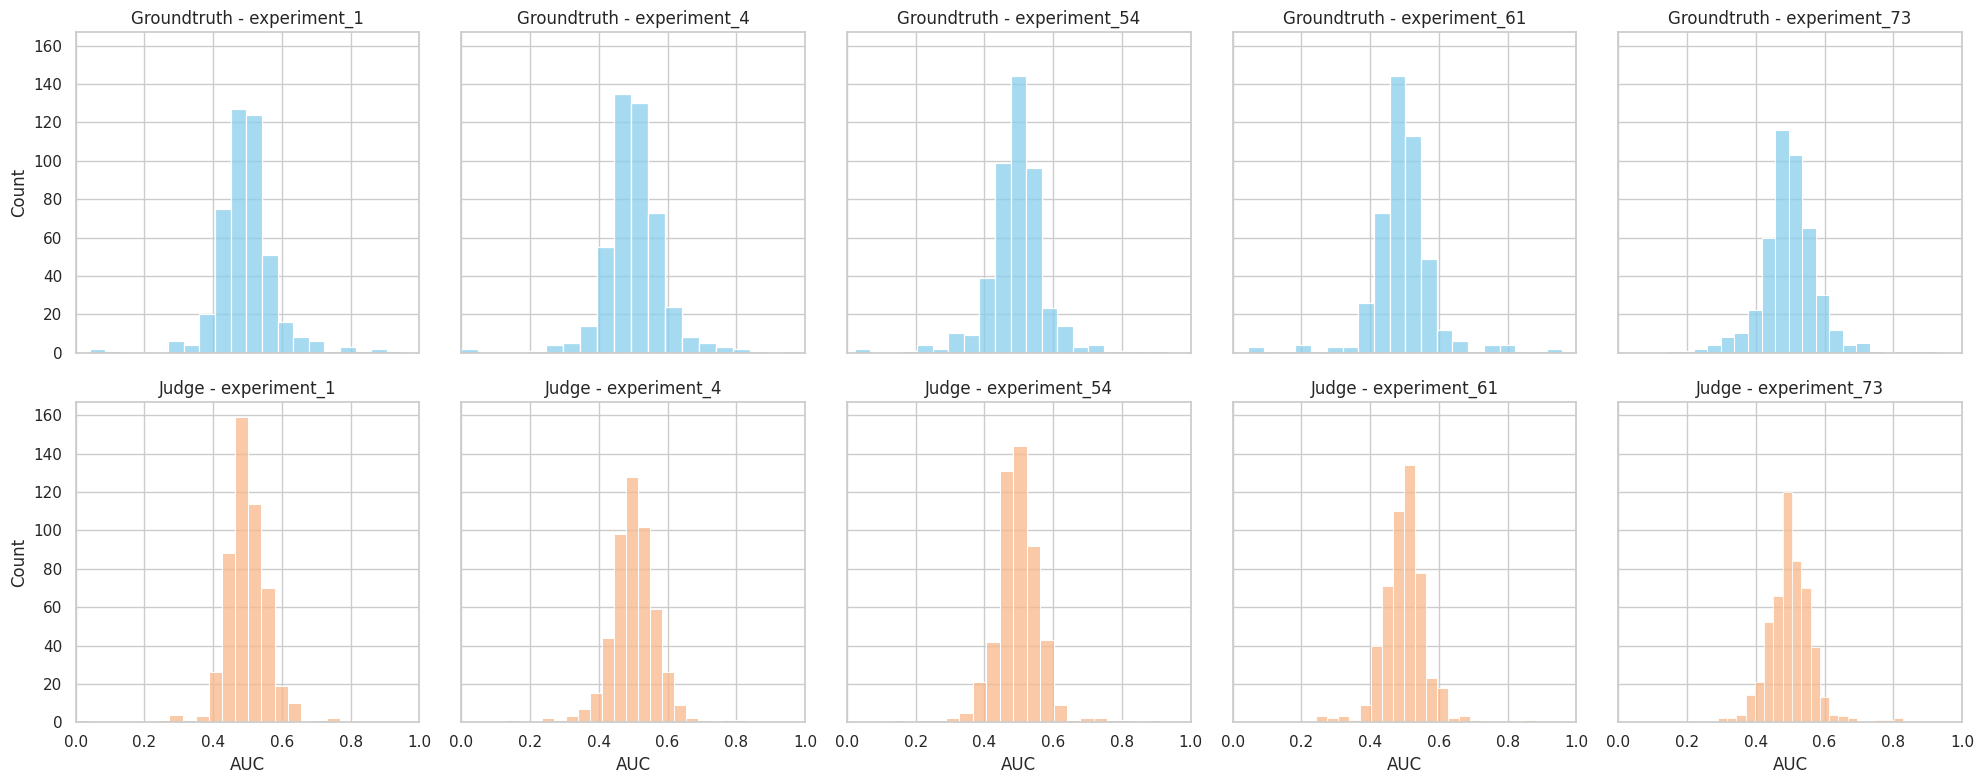

In [ ]:
# Plot AUC histograms per type/experiment using existing eval_df (Polars)
import seaborn as sns
import matplotlib.pyplot as plt

eval_df = pl.DataFrame(_eval_df)
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
color_map = {"groundtruth": "#87CEEB", "judge": "#F8B88B"}  # Pastel blue, pastel orange

for row, t in enumerate(["groundtruth", "judge"]):
    for col, exp in enumerate(EXPERIMENTS):
        subset = eval_df.filter((pl.col("type") == t) & (pl.col("experiment") == exp))
        sns.histplot(data=subset.to_pandas(), x="auc", bins=20, color=color_map[t], ax=axes[row, col])
        axes[row, col].set_title(f"{t.capitalize()} - {exp}")
        axes[row, col].set_xlim(0, 1)
        if col == 0:
            axes[row, col].set_ylabel("Count")
        else:
            axes[row, col].set_ylabel("")
        axes[row, col].set_xlabel("AUC")

plt.tight_layout()
plt.show()

In [ ]:
from utils.metrics.calculate_metric import calculate_agg_metric


wiki = pl.read_ipc(f"../../data/wiki_dump2018_nq_open/processed/wiki.feather")
gold = pl.read_ipc(f"../../data/nq_open_gold/processed/dev.feather")

LOAD = False
if not LOAD:
    dfs_generations = []
    for exp in EXPERIMENTS:
        questions_path = f"runs/{exp}/questions.feather"
        for file in os.listdir(f"runs/{exp}/generations"):
            if "lr_balanced" in file:
                print(f"Processing {file} for experiment {exp}...")
                dfs_generations.append(calculate_agg_metric(
                    metrics=["rouge_l"],
                    generation_path=f"runs/{exp}/generations/{fileb}",
                    reference_path=questions_path    ,
                    saving_path=None            
                )
                .with_columns([
                    pl.lit(exp).alias("experiment"),
                    pl.lit(file.split('_')[2].split('.')[0]).alias("model"),
                ]))

    generations_results = pl.concat(dfs_generations)
    generations_results.write_ipc("generation_results/logistic_regression_balanced.feather")
else:
    generations_results = pl.read_ipc("generation_results/logistic_regression_balanced.feather")        

Processing lr_balanced_groundtruth.json for experiment experiment_1...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_balanced_judge.json for experiment experiment_1...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_balanced_judge.json for experiment experiment_4...


...

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_balanced_groundtruth.json for experiment experiment_73...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_balanced_judge.json for experiment experiment_73...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


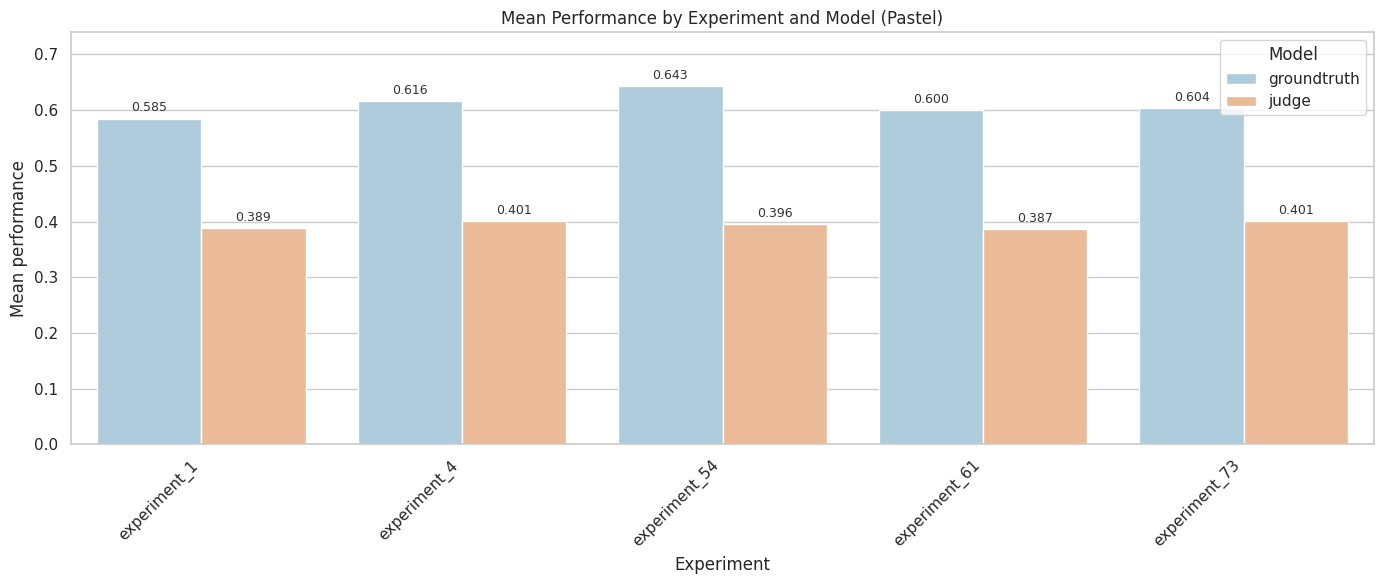

In [ ]:
# Ensure the aggregated column is named `mean`
_df = generations_results.group_by(["experiment", "model"]).agg(pl.col("mean").mean())

_cols = _df.columns
if "mean" in _cols:
    df_plot = _df.rename({"mean": "mean"})
elif "mean_mean" in _cols:
    df_plot = _df.rename({"mean_mean": "mean"})
else:
    # Fallback: assume third column is the aggregated mean
    score_col = [c for c in _cols if c not in ("experiment", "model")][0]
    df_plot = _df.rename({score_col: "mean"})

# Convert to pandas for seaborn
_df_pd = df_plot.to_pandas()

# Limit to requested categories to ensure palette mapping works
wanted_models = ["groundtruth", "judge"]
_df_pd = _df_pd[_df_pd["model"].isin(wanted_models)]

# Pastel palette mapping
palette = {
    "groundtruth": "#a6cee3",  # pastel blue
    "judge": "#F8B88B",        # pastel yellow
}

# Order experiments ascending
order_experiments = sorted(_df_pd["experiment"].unique())
hue_order = wanted_models

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=_df_pd,
    x="experiment",
    y="mean",
    hue="model",
    palette=palette,
    order=order_experiments,
    hue_order=hue_order,
)

plt.title("Mean Performance by Experiment and Model (Pastel)")
plt.xlabel("Experiment")
plt.ylabel("Mean performance")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")

# Show numeric labels above bars
try:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9, color="#333")
except Exception:
    # Fallback for older matplotlib versions
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(f"{height:.3f}",
                    (patch.get_x() + patch.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color="#333",
                    xytext=(0, 3), textcoords='offset points')

# Small headroom for labels
if len(_df_pd):
    plt.ylim(0, _df_pd["mean"].max() * 1.15)

plt.tight_layout()
plt.show()

In [19]:
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm

X_groundtruth_train, y_groundtruth_train, X_judge_train, y_judge_train = get_train_sets(df)
groundtruth_models = []
judge_models = []

with tqdm(total=5 * 500, desc="Training models") as pbar:
    for i in range(5):
        _j_arr, _g_arr = [], []
        for j in range(500):
            # Groundtruth model
            X_gt = X_groundtruth_train[i][j]
            y_gt = y_groundtruth_train[i][j].ravel()
            
            if best_params["groundtruth"][i][j] is None:
                _g_arr.append(None)
            else:
                model_gt = LogisticRegression(**best_params["groundtruth"][i][j], max_iter=1000, random_state=42, class_weight="balanced")
                model_gt.fit(X_gt, y_gt)
                _g_arr.append(model_gt)
            # Judge model
            X_jd = X_judge_train[i][j]
            y_jd = y_judge_train[i][j].ravel()

            if best_params["judge"][i][j] is None:
                _j_arr.append(None)
            else:
                model_jd = LogisticRegression(**best_params["judge"][i][j], max_iter=1000, random_state=42)
                model_jd.fit(X_jd, y_jd)
                _j_arr.append(model_jd)
            

            
            pbar.update(1)
        
        groundtruth_models.append(_g_arr)
        judge_models.append(_j_arr)

del X_groundtruth_train, y_groundtruth_train, X_judge_train, y_judge_train
gc.collect()

Training models:   0%|▍                                                                                                                                             | 7/2500 [00:00<02:02, 20.43it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models:   0%|▌                                                                                                                                            | 10/2500 [00:01<09:46,  4.24it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models:   1%|▉                                                                                                                                            | 17/2500 [00:03<08:04,  5.13it/s]/home/c

422

In [20]:

from numpy import float64


for exp in range(len(EXPERIMENTS)):
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models[exp]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/lr_balanced_weights.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/lr_balanced_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models[exp]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/lr_balanced_bias.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/lr_balanced_bias.pt")


### saving for datamodels generations
for exp in range(len(EXPERIMENTS)):
    jg_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/lr_balanced_judge/"
    gt_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/lr_balanced_groundtruth/"
    os.makedirs(jg_path, exist_ok=True)
    os.makedirs(gt_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models[exp]]), f"{gt_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models[exp]]), f"{jg_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models[exp]]), f"{gt_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models[exp]]), f"{jg_path}/0_499_bias.pt")

/tmp/ipykernel_3200580/254428271.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models[exp]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/lr_balanced_bias.pt")
/tmp/ipykernel_3200580/254428271.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/lr_balanced_bias.pt")
/tmp/ipykernel_3200580/254428271.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, an

In [21]:
from sklearn.metrics import roc_auc_score
X_groundtruth_test, y_groundtruth_test, X_judge_test, y_judge_test = get_test_sets(df)


_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}


for i in range(5):
    for j in range(500):
        
        judge_lr = judge_models[i][j]
        if judge_lr is not None:

            _x = X_judge_test[i][j]
            _y = y_judge_test[i][j].ravel()
            score = roc_auc_score(_y, judge_lr.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("judge")
            _eval_df["auc"].append(score)

        groundtruth_lr = groundtruth_models[i][j]
        if groundtruth_lr is not None:
            _x = X_groundtruth_test[i][j]
            _y = y_groundtruth_test[i][j].ravel()
            score = roc_auc_score(_y, groundtruth_lr.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("groundtruth")
            _eval_df["auc"].append(score)



del X_groundtruth_test, y_groundtruth_test, X_judge_test, y_judge_test
gc.collect()

/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarnin

0

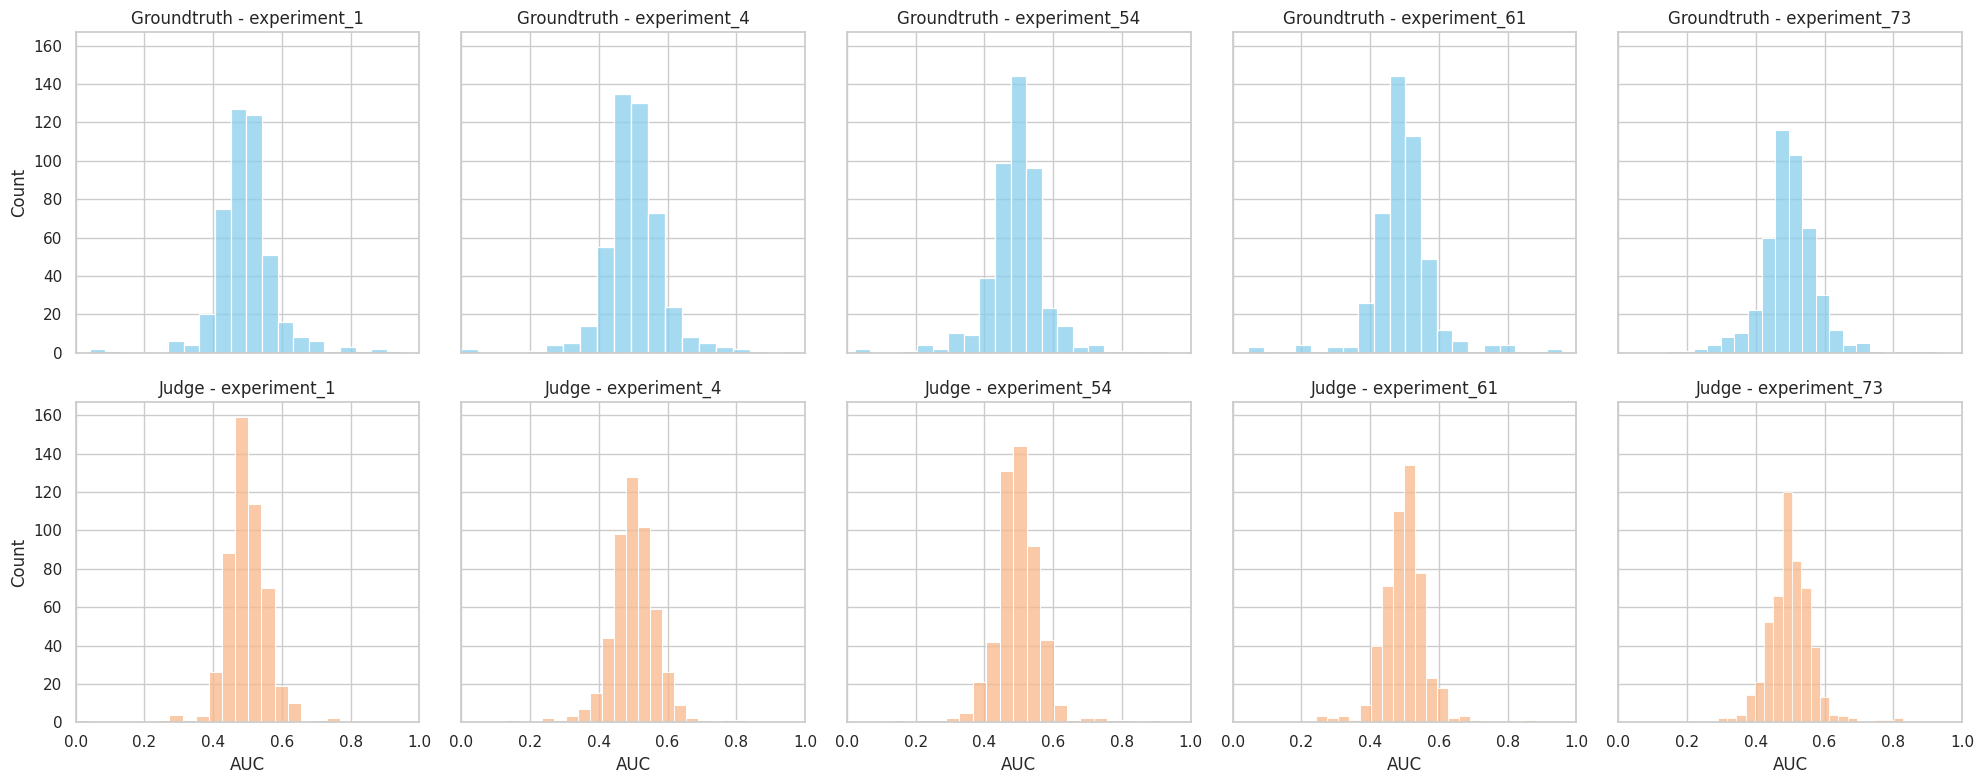

In [22]:
# Plot AUC histograms per type/experiment using existing eval_df (Polars)
import seaborn as sns
import matplotlib.pyplot as plt

eval_df = pl.DataFrame(_eval_df)
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
color_map = {"groundtruth": "#87CEEB", "judge": "#F8B88B"}  # Pastel blue, pastel orange

for row, t in enumerate(["groundtruth", "judge"]):
    for col, exp in enumerate(EXPERIMENTS):
        subset = eval_df.filter((pl.col("type") == t) & (pl.col("experiment") == exp))
        sns.histplot(data=subset.to_pandas(), x="auc", bins=20, color=color_map[t], ax=axes[row, col])
        axes[row, col].set_title(f"{t.capitalize()} - {exp}")
        axes[row, col].set_xlim(0, 1)
        if col == 0:
            axes[row, col].set_ylabel("Count")
        else:
            axes[row, col].set_ylabel("")
        axes[row, col].set_xlabel("AUC")

plt.tight_layout()
plt.show()

In [27]:
from utils.metrics.calculate_metric import calculate_agg_metric


wiki = pl.read_ipc(f"../../data/wiki_dump2018_nq_open/processed/wiki.feather")
gold = pl.read_ipc(f"../../data/nq_open_gold/processed/dev.feather")

LOAD = False
if not LOAD:
    dfs_generations = []
    for exp in EXPERIMENTS:
        questions_path = f"runs/{exp}/questions.feather"
        for file in os.listdir(f"runs/{exp}/generations"):
            if "lr_balanced" in file:
                print(f"Processing {file} for experiment {exp}...")
                dfs_generations.append(calculate_agg_metric(
                    metrics=["rouge_l"],
                    generation_path=f"runs/{exp}/generations/{fileb}",
                    reference_path=questions_path    ,
                    saving_path=None            
                )
                .with_columns([
                    pl.lit(exp).alias("experiment"),
                    pl.lit(file.split('_')[2].split('.')[0]).alias("model"),
                ]))

    generations_results = pl.concat(dfs_generations)
    generations_results.write_ipc("generation_results/logistic_regression_balanced.feather")
else:
    generations_results = pl.read_ipc("generation_results/logistic_regression_balanced.feather")        

Processing lr_balanced_groundtruth.json for experiment experiment_1...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_balanced_judge.json for experiment experiment_1...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_balanced_judge.json for experiment experiment_4...


...

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_balanced_groundtruth.json for experiment experiment_73...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_balanced_judge.json for experiment experiment_73...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


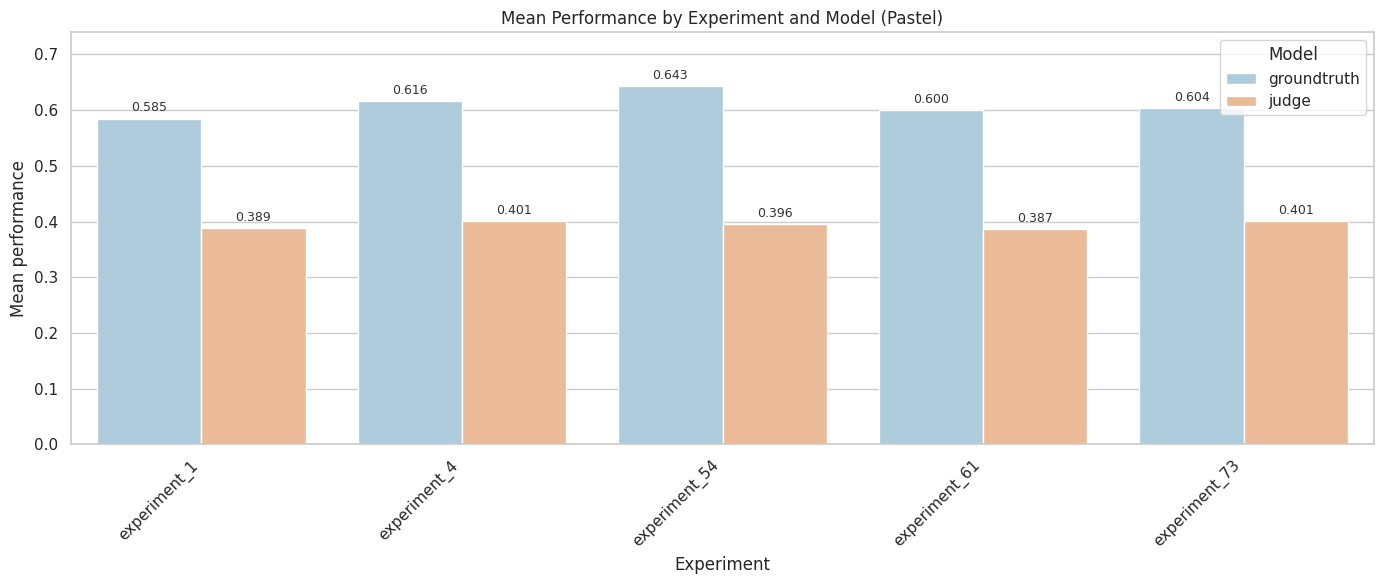

In [28]:
# Ensure the aggregated column is named `mean`
_df = generations_results.group_by(["experiment", "model"]).agg(pl.col("mean").mean())

_cols = _df.columns
if "mean" in _cols:
    df_plot = _df.rename({"mean": "mean"})
elif "mean_mean" in _cols:
    df_plot = _df.rename({"mean_mean": "mean"})
else:
    # Fallback: assume third column is the aggregated mean
    score_col = [c for c in _cols if c not in ("experiment", "model")][0]
    df_plot = _df.rename({score_col: "mean"})

# Convert to pandas for seaborn
_df_pd = df_plot.to_pandas()

# Limit to requested categories to ensure palette mapping works
wanted_models = ["groundtruth", "judge"]
_df_pd = _df_pd[_df_pd["model"].isin(wanted_models)]

# Pastel palette mapping
palette = {
    "groundtruth": "#a6cee3",  # pastel blue
    "judge": "#F8B88B",        # pastel yellow
}

# Order experiments ascending
order_experiments = sorted(_df_pd["experiment"].unique())
hue_order = wanted_models

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=_df_pd,
    x="experiment",
    y="mean",
    hue="model",
    palette=palette,
    order=order_experiments,
    hue_order=hue_order,
)

plt.title("Mean Performance by Experiment and Model (Pastel)")
plt.xlabel("Experiment")
plt.ylabel("Mean performance")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")

# Show numeric labels above bars
try:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9, color="#333")
except Exception:
    # Fallback for older matplotlib versions
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(f"{height:.3f}",
                    (patch.get_x() + patch.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color="#333",
                    xytext=(0, 3), textcoords='offset points')

# Small headroom for labels
if len(_df_pd):
    plt.ylim(0, _df_pd["mean"].max() * 1.15)

plt.tight_layout()
plt.show()

## Training Holdout Binary Classification

In [7]:
## Load best param
import json


best_params_holdout = {
    "judge": [],
    "groundtruth": []
}

for f in sorted(os.listdir("best_params")):
    _params = []
    if "holdout" in f:
        results = json.load(open(f"best_params/{f}", "r"))["results"]
        for p in results:
            try:
                _params.append(p["best_params"])
            except KeyError:
                _params.append(None)
        
        if "judge" in f:
            best_params_holdout["judge"].append(_params)
        else:
            best_params_holdout["groundtruth"].append(_params)

In [10]:
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm

X_groundtruth_train, y_groundtruth_train, X_judge_train, y_judge_train = get_train_sets(df)
groundtruth_holdout_models = []
judge_holdout_models = []

with tqdm(total=5 * 500, desc="Training models") as pbar:
    for i in range(5):
        _j_arr, _g_arr = [], []
        for j in range(500):
            # Groundtruth model
            X_gt = X_groundtruth_train[i][j]
            y_gt = y_groundtruth_train[i][j].ravel()
            
            if best_params_holdout["groundtruth"][i][j] is None:
                _g_arr.append(None)
            else:
                model_gt = LogisticRegression(**best_params_holdout["groundtruth"][i][j], max_iter=1000, random_state=42)
                model_gt.fit(X_gt, y_gt)
                _g_arr.append(model_gt)
            # Judge model
            X_jd = X_judge_train[i][j]
            y_jd = y_judge_train[i][j].ravel()

            if best_params_holdout["judge"][i][j] is None:
                _j_arr.append(None)
            else:
                model_jd = LogisticRegression(**best_params_holdout["judge"][i][j], max_iter=1000, random_state=42)
                model_jd.fit(X_jd, y_jd)
                _j_arr.append(model_jd)
            

            
            pbar.update(1)
        
        groundtruth_holdout_models.append(_g_arr)
        judge_holdout_models.append(_j_arr)

del X_groundtruth_train, y_groundtruth_train, X_judge_train, y_judge_train
gc.collect()

Training models:   5%|███▍                                                                    | 120/2500 [00:22<18:32,  2.14it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models:   9%|██████▎                                                                 | 218/2500 [00:42<06:16,  6.05it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models:  31%|██████████████████████                                                  | 766/2500 [02:34<06:42,  4.31it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training m

499

In [11]:



from numpy import float64

for exp in range(len(EXPERIMENTS)):
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_holdout_models[exp]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/holdout_weights.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_holdout_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/holdout_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_holdout_models[exp]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/holdout_bias.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_holdout_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/holdout_bias.pt")


### saving for datamodels generations
for exp in range(len(EXPERIMENTS)):
    jg_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/houldout_judge/"
    gt_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/holdout_groundtruth/"
    os.makedirs(jg_path, exist_ok=True)
    os.makedirs(gt_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_holdout_models[exp]]), f"{gt_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_holdout_models[exp]]), f"{jg_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_holdout_models[exp]]), f"{gt_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_holdout_models[exp]]), f"{jg_path}/0_499_bias.pt")

/tmp/ipykernel_3278967/1614606696.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_holdout_models[exp]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/holdout_weights.pt")
/tmp/ipykernel_3278967/1614606696.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_holdout_models[exp]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/holdout_bias.pt")
/tmp/ipykernel_3278967/1614606696.py:7

In [12]:
from sklearn.metrics import roc_auc_score
X_groundtruth_test, y_groundtruth_test, X_judge_test, y_judge_test = get_test_sets(df)


_holdout_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}


for i in range(5):
    for j in range(500):
        
        judge_lr = judge_holdout_models[i][j]
        if judge_lr is not None:

            _x = X_judge_test[i][j]
            _y = y_judge_test[i][j].ravel()
            score = roc_auc_score(_y, judge_lr.predict_proba(_x)[:, 1])

            _holdout_eval_df["experiment"].append(EXPERIMENTS[i])
            _holdout_eval_df["type"].append("judge")
            _holdout_eval_df["auc"].append(score)

        groundtruth_lr = groundtruth_holdout_models[i][j]
        if groundtruth_lr is not None:
            _x = X_groundtruth_test[i][j]
            _y = y_groundtruth_test[i][j].ravel()
            score = roc_auc_score(_y, groundtruth_lr.predict_proba(_x)[:, 1])

            _holdout_eval_df["experiment"].append(EXPERIMENTS[i])
            _holdout_eval_df["type"].append("groundtruth")
            _holdout_eval_df["auc"].append(score)



del X_groundtruth_test, y_groundtruth_test, X_judge_test, y_judge_test
gc.collect()

/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarnin

0

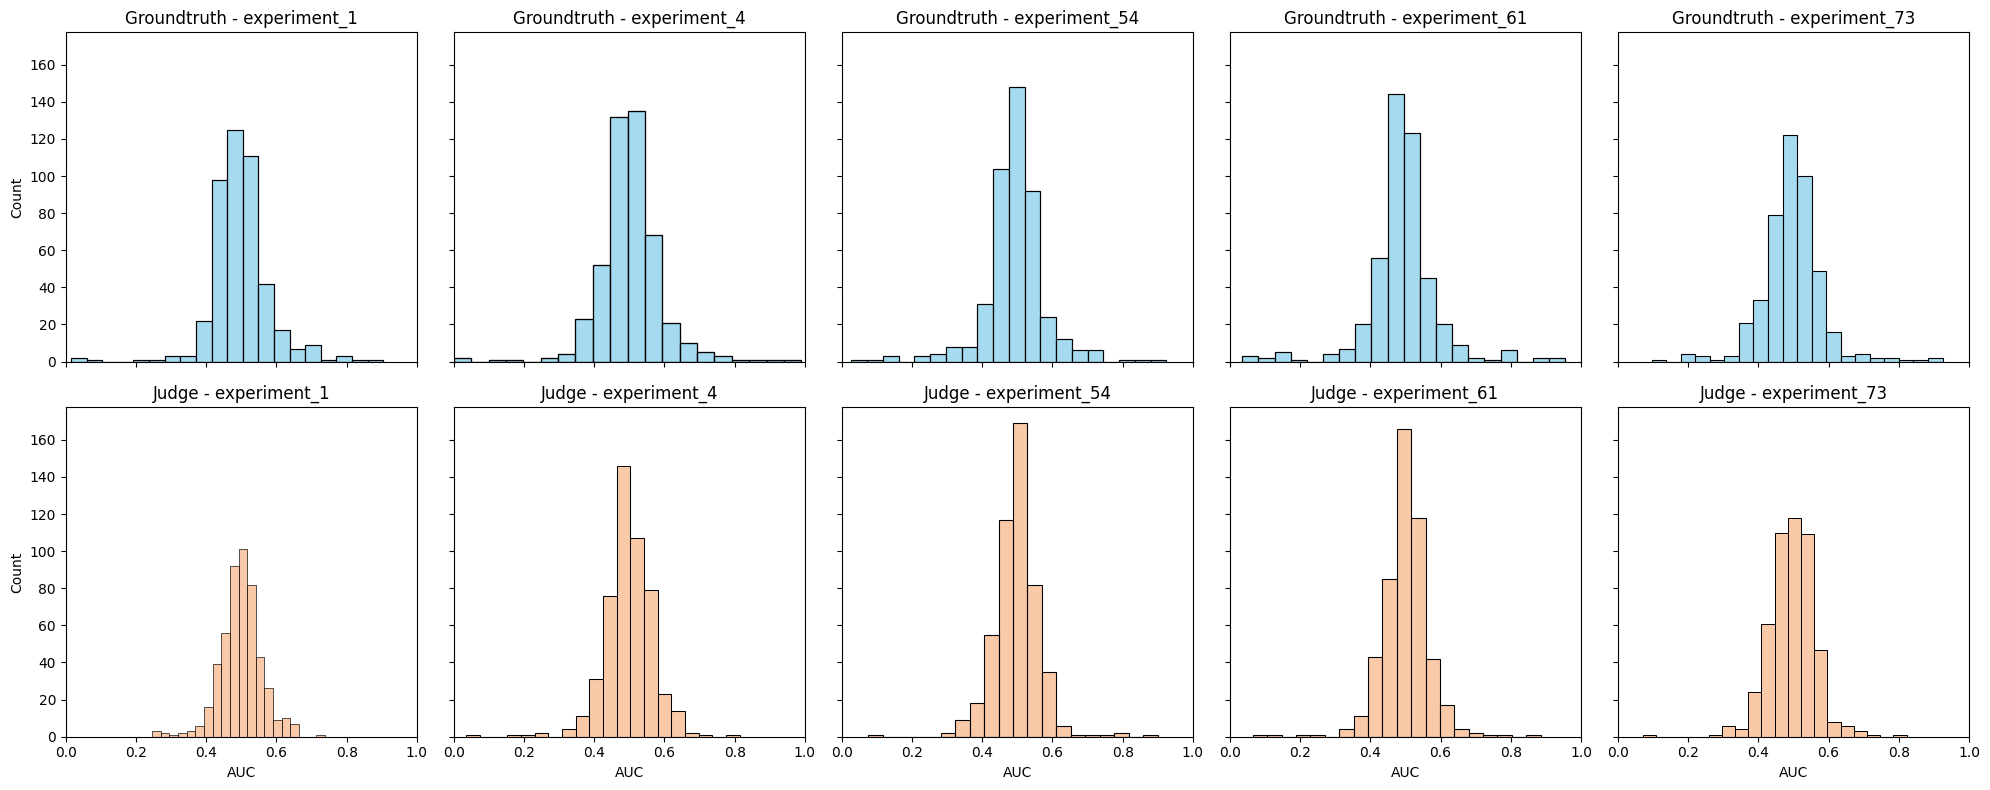

In [14]:
# Plot AUC histograms per type/experiment using existing eval_df (Polars)
import seaborn as sns
import matplotlib.pyplot as plt

holdout_eval_df = pl.DataFrame(_holdout_eval_df)
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
color_map = {"groundtruth": "#87CEEB", "judge": "#F8B88B"}  # Pastel blue, pastel orange

for row, t in enumerate(["groundtruth", "judge"]):
    for col, exp in enumerate(EXPERIMENTS):
        subset = holdout_eval_df.filter((pl.col("type") == t) & (pl.col("experiment") == exp))
        sns.histplot(data=subset.to_pandas(), x="auc", bins=20, color=color_map[t], ax=axes[row, col])
        axes[row, col].set_title(f"{t.capitalize()} - {exp}")
        axes[row, col].set_xlim(0, 1)
        if col == 0:
            axes[row, col].set_ylabel("Count")
        else:
            axes[row, col].set_ylabel("")
        axes[row, col].set_xlabel("AUC")

plt.tight_layout()
plt.show()